# AML s26 - Support Vector Classifier (Soft-Margin SVM)

The **support vector classifier** extends the maximal margin classifier → we deliberately allow some misclassifications to get a wider, more robust margin

The hyperparameter **C (cost)** controls the bias–variance trade-off:
- **Large C** → small tolerance for violations → narrow margin, low bias, high variance  
- **Small C** → large tolerance for violations → wide margin, higher bias, lower variance

### Load libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

### Generate Overlapping Data (--> no hard-margin solution exists)

In [2]:
np.random.seed(0)

n = 30
X_neg = np.random.randn(n, 2) + np.array([-1, -1])
X_pos = np.random.randn(n, 2) + np.array([ 1,  1])

X = np.vstack([X_neg, X_pos])
y = np.hstack([np.full(n, -1), np.full(n, 1)])

print(f"{X.shape[0]} points ")

60 points 


### Fit SVCs for several values of C

In [3]:
C_values = [0.01, 0.1, 1.0, 100.0]
clfs = {C: SVC(kernel='linear', C=C).fit(X, y) for C in C_values}

### Visualize the effect of C

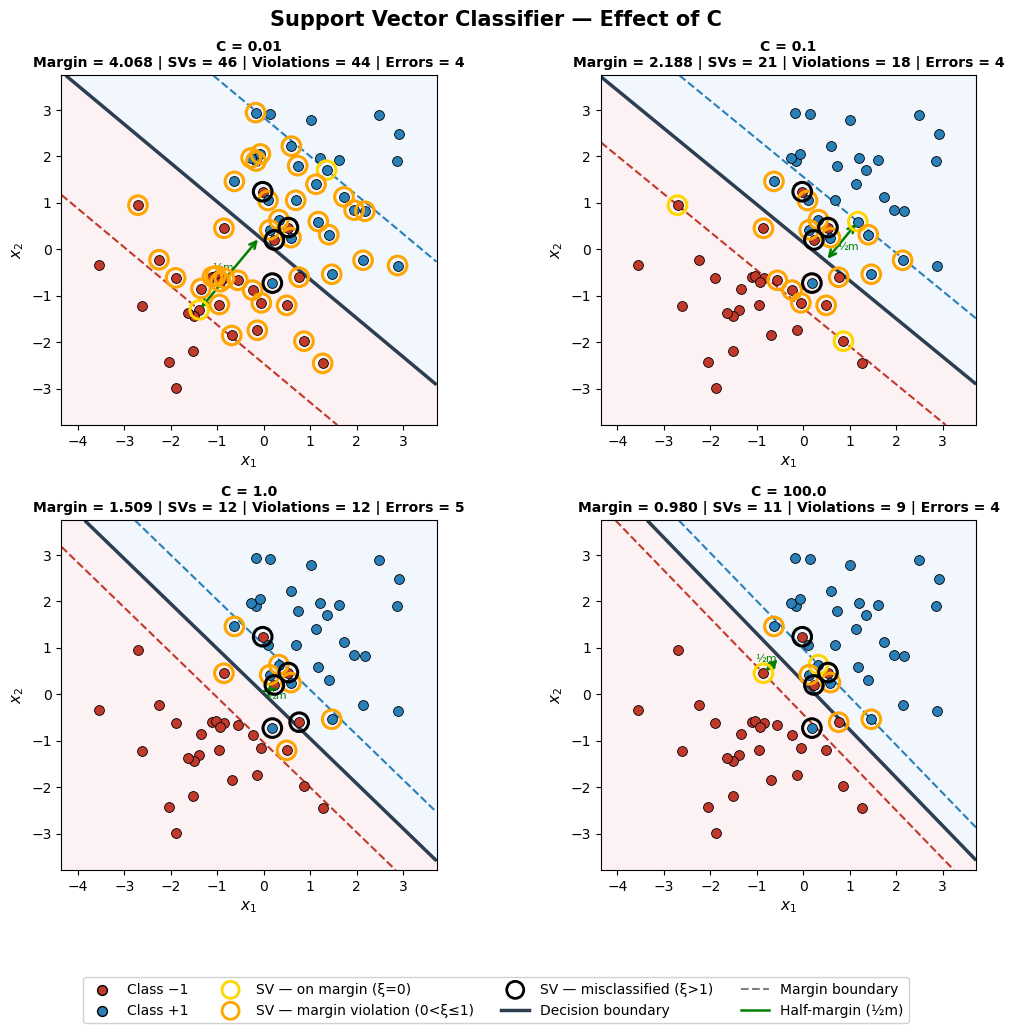

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

# ── shared grid ────────────────────────────────────────────────────
pad = 0.8
x1_min, x1_max = X[:, 0].min() - pad, X[:, 0].max() + pad
x2_min, x2_max = X[:, 1].min() - pad, X[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 400),np.linspace(x2_min, x2_max, 400))

for ax, C in zip(axes.ravel(), C_values):
    clf = clfs[C]
    w   = clf.coef_[0]
    b   = clf.intercept_[0]
    margin = 2 / np.linalg.norm(w)
    n_sv   = clf.support_vectors_.shape[0]

    # slack variables (ξ_i): signed distance violation ──────────
    # ξ_i = max(0, 1 - y_i(w·x_i + b))
    scores = y * (X @ w + b)
    xi  = np.maximum(0, 1 - scores)          # slack for every point
    n_violations = (xi > 0).sum()               # inside or beyond margin
    n_errors      = (xi > 1).sum()              # actual misclassifications

    # decision regions  ──────────────────────────────────────────
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1e6, 0, 1e6],  colors=['#FADADD', '#DAE8FC'], alpha=0.35)

    # decision boundary + margin lines
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors=['#c0392b', '#2c3e50', '#2980b9'],  linewidths=[1.5, 2.5, 1.5])

    # ── data points, coloured by class ────────────────────────────
    for cls, col in [(-1, '#c0392b'), (1, '#2980b9')]:
        mask = y == cls
        ax.scatter(*X[mask].T, color=col, edgecolors='k',
                   s=50, zorder=3, linewidths=0.6)

    # ── support vectors: classify each by its slack ξ_i ──────────
    # ξ ≈ 0      → on the margin boundary (gold ring)
    # 0 < ξ ≤ 1  → inside margin, correct side (orange ring)
    # ξ > 1      → misclassified (red X)
    sv_scores = y[clf.support_] * (clf.support_vectors_ @ w + b)
    sv_xi     = np.maximum(0, 1 - sv_scores)
    mask_ok  = sv_xi <= 1e-6
    mask_vio = (sv_xi > 1e-6) & (sv_xi <= 1)
    mask_err = sv_xi > 1
    if mask_ok.any():
        ax.scatter(*clf.support_vectors_[mask_ok].T, s=180, facecolors='none', edgecolors='gold',linewidths=2.2, zorder=4)
    if mask_vio.any():
        ax.scatter(*clf.support_vectors_[mask_vio].T,  s=180, facecolors='none', edgecolors='orange', linewidths=2.2, zorder=4)
    if mask_err.any():
        ax.scatter(*clf.support_vectors_[mask_err].T, s=180, facecolors='none', edgecolors='black', linewidths=2.2, zorder=5)

    # ── margin width arrow (perpendicular to boundary) ────────────
    # Only anchor on a gold SV (ξ≈0) so the arrow truly spans the half-margin.
    # Fall back to the closest SV if none are exactly on the margin.
    centre = np.array([(x1_min+x1_max)/2, (x2_min+x2_max)/2])
    candidates = clf.support_vectors_[mask_ok] if mask_ok.any() else clf.support_vectors_
    sv_idx = np.argmin(np.linalg.norm(candidates - centre, axis=1))
    sv  = candidates[sv_idx]
    foot = sv - (np.dot(w, sv) + b) / np.dot(w, w) * w   # foot on boundary
    ax.annotate('', xy=foot, xytext=sv, arrowprops=dict(arrowstyle='<->', color='green', lw=1.8, mutation_scale=12))
    mid = (sv + foot) / 2
    # offset label perpendicular to the arrow direction
    perp = np.array([-(foot-sv)[1], (foot-sv)[0]])
    perp /= np.linalg.norm(perp) + 1e-12
    label_pos = mid + 0.18 * perp
    ax.text(*label_pos, '½m', color='green', fontsize=8, ha='center', va='center')

    ax.set_aspect('equal')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.set_xlabel('$x_1$', fontsize=11)
    ax.set_ylabel('$x_2$', fontsize=11)
    ax.set_title(
        f'C = {C}\n'
        f'Margin = {margin:.3f} | SVs = {n_sv} | '
        f'Violations = {n_violations} | Errors = {n_errors}',
        fontsize=10, fontweight='bold'
    )

# shared legend
from matplotlib.lines import Line2D
handles = [
    plt.scatter([], [], color='#c0392b', edgecolors='k', s=50, label='Class −1'),
    plt.scatter([], [], color='#2980b9', edgecolors='k', s=50, label='Class +1'),
    plt.scatter([], [], s=150, facecolors='none', edgecolors='gold', linewidths=2, label='SV — on margin (ξ=0)'),
    plt.scatter([], [], s=150, facecolors='none', edgecolors='orange', linewidths=2, label='SV — margin violation (0<ξ≤1)'),
    plt.scatter([], [], s=150, facecolors='none', edgecolors='black', linewidths=2, label='SV — misclassified (ξ>1)'),
    Line2D([0], [0], color='#2c3e50', lw=2.5, label='Decision boundary'),
    Line2D([0], [0], color='gray',    lw=1.5, ls='--', label='Margin boundary'),
    Line2D([0], [0], color='green',   lw=1.8, label='Half-margin (½m)'),
]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.04), frameon=True, framealpha=0.9)

fig.suptitle('Support Vector Classifier — Effect of C', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### Analyze margin width and number of support vectors as a function of C

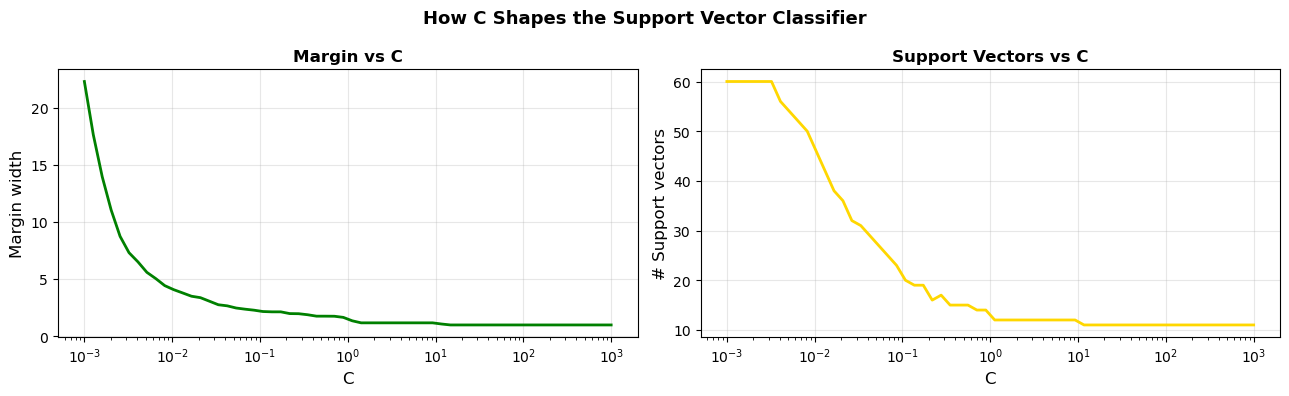

In [5]:
C_range = np.logspace(-3, 3, 60)
margins, n_svs = [], []

for C in C_range:
    clf = SVC(kernel='linear', C=C).fit(X, y)
    w   = clf.coef_[0]
    margins.append(2 / np.linalg.norm(w))
    n_svs.append(clf.support_vectors_.shape[0])
    scores = y * (X @ w + clf.intercept_[0])
    xi = np.maximum(0, 1 - scores)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(C_range, margins, color='green', lw=2)
axes[0].set_xlabel('C', fontsize=12); axes[0].set_ylabel('Margin width', fontsize=12)
axes[0].set_title('Margin vs C', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(C_range, n_svs, color='gold', lw=2, markevery=5)
axes[1].set_xlabel('C', fontsize=12); axes[1].set_ylabel('# Support vectors', fontsize=12)
axes[1].set_title('Support Vectors vs C', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.suptitle('How C Shapes the Support Vector Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()